# Stochastic Transition — Visual Experiments

> **Goal:** See what a transition distribution represents, how likelihood learns uncertainty, and where Gaussian summaries fail.

## What we will explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Heteroscedastic transition** | Why should predicted variance depend on state and action? |
| 2 | **Gaussian NLL and reparameterization** | How does likelihood balance mean error and uncertainty? |
| 3 | **Multimodal futures** | Why can a single Gaussian assign mass to impossible states? |
| 4 | **Aleatoric vs epistemic uncertainty** | What does ensemble disagreement reveal outside the data region? |
| 5 | **Particle rollout** | What information is lost by mean propagation and moment matching? |

**Linked theory:** [Stochastic Transition](../research/03-stochastic-transition.md)

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})

def normal_density(values, mean, standard_deviation):
    coefficient = 1.0 / (np.sqrt(2.0 * np.pi) * standard_deviation)
    exponent = -0.5 * ((values - mean) / standard_deviation) ** 2
    return coefficient * np.exp(exponent)

---
## Experiment 1: Variance is part of the transition

**Question:** Why is one global noise scale insufficient when transition uncertainty changes across latent space?

We generate a one-dimensional transition whose mean is smooth but whose process noise grows with the magnitude of the current state. A deterministic predictor can follow the center, yet it cannot express how confidence changes by region.

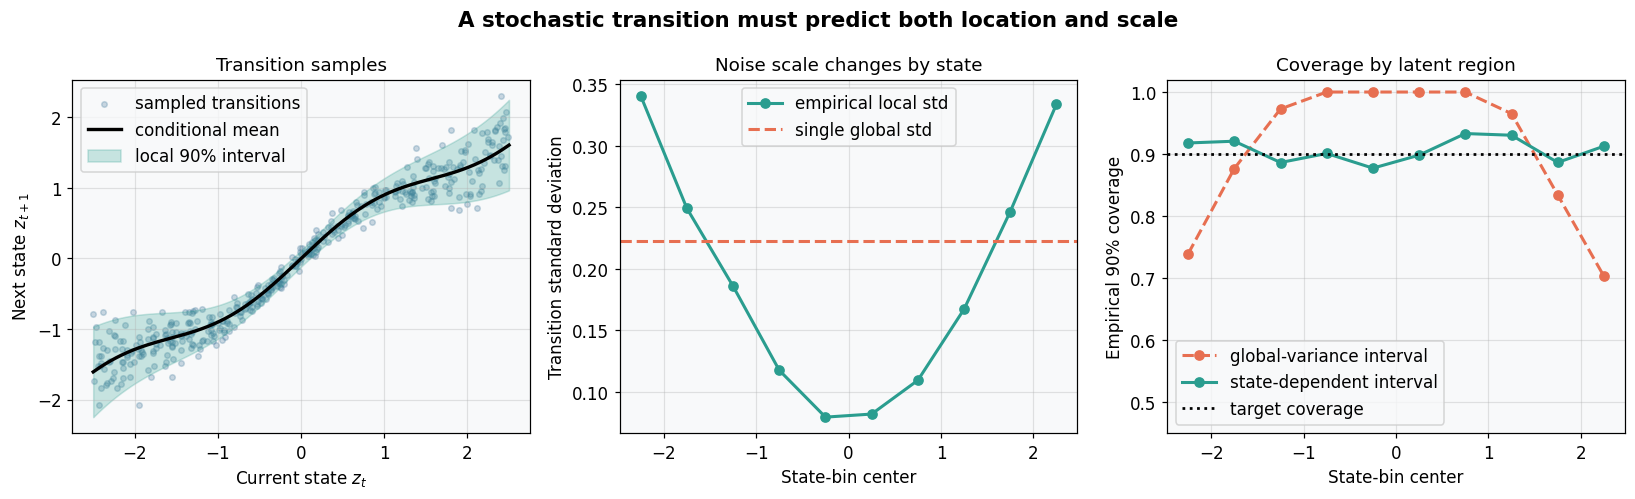

In [2]:
np.random.seed(1)
sample_count = 2200
current_state = np.random.uniform(-2.5, 2.5, sample_count)
true_mean = 0.72 * current_state + 0.20 * np.sin(2.0 * current_state)
true_sigma = 0.07 + 0.32 * (np.abs(current_state) / 2.5) ** 1.6
next_state = true_mean + true_sigma * np.random.randn(sample_count)

mean_coefficients = np.polyfit(current_state, next_state, deg=3)
predicted_mean = np.polyval(mean_coefficients, current_state)
global_sigma = np.std(next_state - predicted_mean)

state_grid = np.linspace(-2.5, 2.5, 400)
grid_mean = 0.72 * state_grid + 0.20 * np.sin(2.0 * state_grid)
grid_sigma = 0.07 + 0.32 * (np.abs(state_grid) / 2.5) ** 1.6

bin_edges = np.linspace(-2.5, 2.5, 11)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
global_coverage = []
local_coverage = []
empirical_sigma = []
for lower, upper in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (current_state >= lower) & (current_state < upper)
    residual = next_state[mask] - true_mean[mask]
    empirical_sigma.append(np.std(residual))
    global_coverage.append(np.mean(np.abs(residual) <= 1.645 * global_sigma))
    local_coverage.append(np.mean(np.abs(residual) <= 1.645 * true_sigma[mask]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
fig.suptitle('A stochastic transition must predict both location and scale', fontsize=14, fontweight='bold')

axes[0].scatter(current_state[::5], next_state[::5], s=13, alpha=0.28, color='#457b9d', label='sampled transitions')
axes[0].plot(state_grid, grid_mean, color='black', linewidth=2.2, label='conditional mean')
axes[0].fill_between(state_grid, grid_mean - 1.645 * grid_sigma, grid_mean + 1.645 * grid_sigma, color='#2a9d8f', alpha=0.24, label='local 90% interval')
axes[0].set_title('Transition samples')
axes[0].set_xlabel('Current state $z_t$')
axes[0].set_ylabel('Next state $z_{t+1}$')
axes[0].legend()

axes[1].plot(bin_centers, empirical_sigma, 'o-', color='#2a9d8f', linewidth=2.0, label='empirical local std')
axes[1].axhline(global_sigma, color='#e76f51', linestyle='--', linewidth=2.0, label='single global std')
axes[1].set_title('Noise scale changes by state')
axes[1].set_xlabel('State-bin center')
axes[1].set_ylabel('Transition standard deviation')
axes[1].legend()

axes[2].plot(bin_centers, global_coverage, 'o--', color='#e76f51', linewidth=2.0, label='global-variance interval')
axes[2].plot(bin_centers, local_coverage, 'o-', color='#2a9d8f', linewidth=2.0, label='state-dependent interval')
axes[2].axhline(0.90, color='black', linestyle=':', linewidth=1.8, label='target coverage')
axes[2].set_ylim(0.45, 1.02)
axes[2].set_title('Coverage by latent region')
axes[2].set_xlabel('State-bin center')
axes[2].set_ylabel('Empirical 90% coverage')
axes[2].legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plots show:** Transition samples form a narrow band near the center and a wider band at large $|z_t|$. A single global standard deviation over-covers the center and under-covers the edges, while the state-dependent interval stays near its target coverage.
2. **Why it looks this way:** The conditional mean describes predictable motion, whereas heteroscedastic variance describes process noise specific to each state region. Averaging those scales destroys local calibration.
3. **Key takeaway:** A Gaussian transition is useful only when its variance head learns where the dynamics are uncertain, not merely one dataset-wide residual scale.

---
## Experiment 2: Gaussian likelihood balances error and uncertainty

**Question:** Why can a Gaussian model not reduce negative log-likelihood by increasing variance without limit?

The Gaussian NLL contains a precision-weighted squared error and a log-variance penalty. We visualize their joint optimum and then show reparameterization as an affine transformation of parameter-free noise.

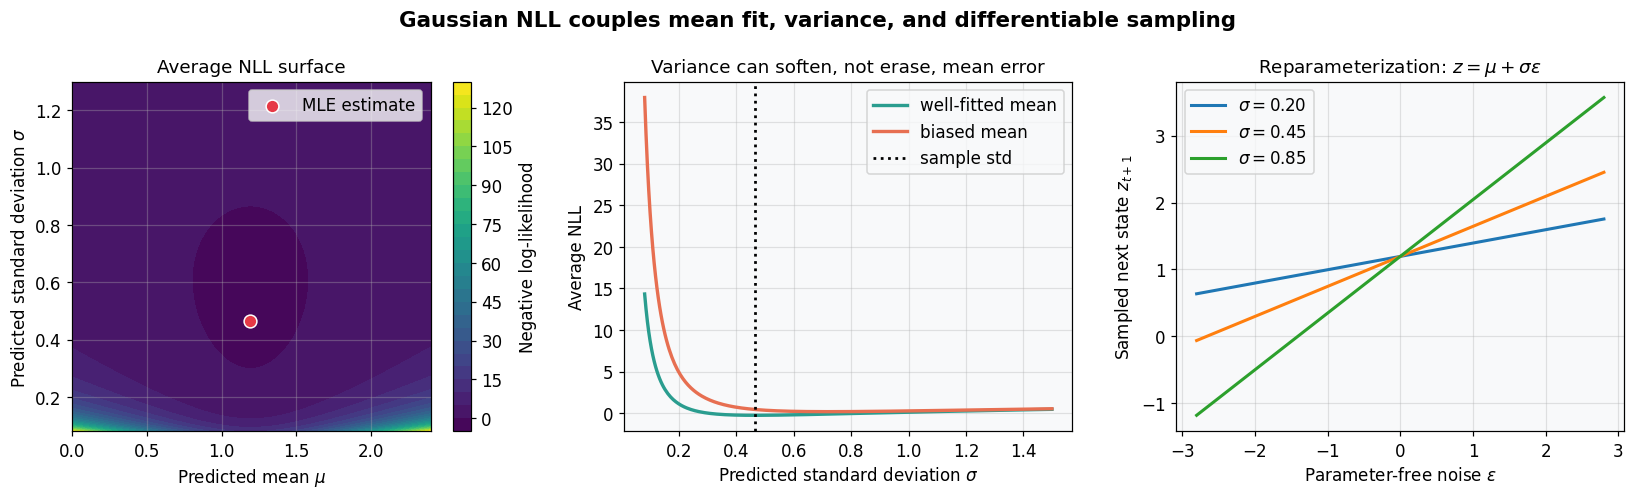

In [3]:
np.random.seed(2)
observations = 1.20 + 0.45 * np.random.randn(500)
mean_grid = np.linspace(0.0, 2.4, 180)
sigma_grid = np.linspace(0.08, 1.30, 170)
mean_mesh, sigma_mesh = np.meshgrid(mean_grid, sigma_grid)
average_nll = np.mean(
    0.5 * (((observations[None, None, :] - mean_mesh[:, :, None]) / sigma_mesh[:, :, None]) ** 2
           + 2.0 * np.log(sigma_mesh[:, :, None])),
    axis=2,
)
sample_mean = np.mean(observations)
sample_sigma = np.std(observations)

sigma_curve = np.linspace(0.08, 1.5, 300)
nll_correct_mean = np.mean(0.5 * (((observations[None, :] - sample_mean) / sigma_curve[:, None]) ** 2 + 2.0 * np.log(sigma_curve[:, None])), axis=1)
biased_mean = sample_mean + 0.55
nll_biased_mean = np.mean(0.5 * (((observations[None, :] - biased_mean) / sigma_curve[:, None]) ** 2 + 2.0 * np.log(sigma_curve[:, None])), axis=1)

epsilon = np.linspace(-2.8, 2.8, 100)
reparameterized_scales = [0.20, 0.45, 0.85]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
fig.suptitle('Gaussian NLL couples mean fit, variance, and differentiable sampling', fontsize=14, fontweight='bold')

contours = axes[0].contourf(mean_mesh, sigma_mesh, average_nll, levels=28, cmap='viridis')
axes[0].scatter([sample_mean], [sample_sigma], color='#e63946', s=70, edgecolor='white', label='MLE estimate')
axes[0].set_title('Average NLL surface')
axes[0].set_xlabel('Predicted mean $\mu$')
axes[0].set_ylabel('Predicted standard deviation $\sigma$')
axes[0].legend()
fig.colorbar(contours, ax=axes[0], label='Negative log-likelihood')

axes[1].plot(sigma_curve, nll_correct_mean, color='#2a9d8f', linewidth=2.2, label='well-fitted mean')
axes[1].plot(sigma_curve, nll_biased_mean, color='#e76f51', linewidth=2.2, label='biased mean')
axes[1].axvline(sample_sigma, color='black', linestyle=':', linewidth=1.8, label='sample std')
axes[1].set_title('Variance can soften, not erase, mean error')
axes[1].set_xlabel('Predicted standard deviation $\sigma$')
axes[1].set_ylabel('Average NLL')
axes[1].legend()

for scale in reparameterized_scales:
    axes[2].plot(epsilon, sample_mean + scale * epsilon, linewidth=2.0, label=f'$\sigma={scale:.2f}$')
axes[2].set_title(r'Reparameterization: $z=\mu+\sigma\epsilon$')
axes[2].set_xlabel('Parameter-free noise $\epsilon$')
axes[2].set_ylabel('Sampled next state $z_{t+1}$')
axes[2].legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plots show:** The NLL surface has a finite optimum near the empirical mean and standard deviation. A biased mean prefers a wider distribution, but its best loss remains worse. Reparameterized samples are straight-line transformations of the same base noise.
2. **Why it looks this way:** The squared-error term discourages variance that is too small, while the log-variance term discourages variance that is too large. Reparameterization moves randomness into $\epsilon$, leaving $\mu$ and $\sigma$ on a differentiable path.
3. **Key takeaway:** Learned variance can acknowledge irreducible residuals, but likelihood still rewards an accurate mean and penalizes indiscriminate uncertainty inflation.

---
## Experiment 3: One Gaussian can invent an impossible future

**Question:** What is lost when two valid transition modes are compressed into one Gaussian?

A latent transition has two symmetric outcomes with an invalid gap between them. We compare the maximum-likelihood single Gaussian with a two-component mixture.

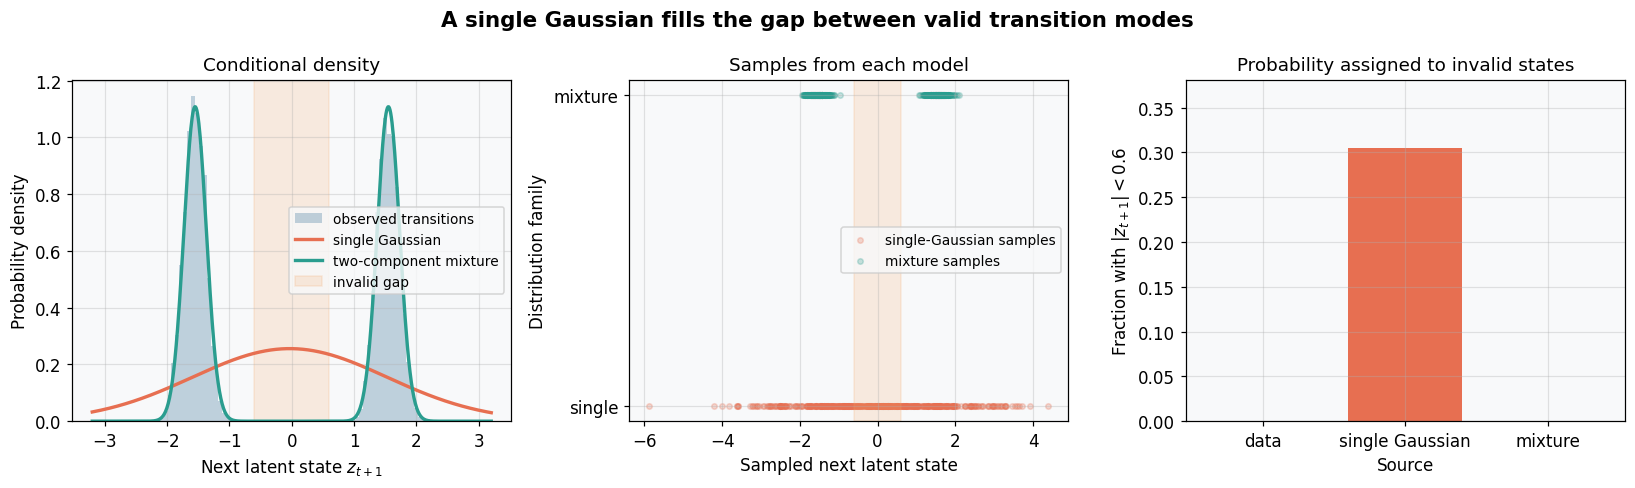

In [4]:
np.random.seed(3)
sample_count = 5000
mode = np.random.choice([-1.0, 1.0], size=sample_count)
transition_samples = 1.55 * mode + 0.18 * np.random.randn(sample_count)
single_mean = np.mean(transition_samples)
single_sigma = np.std(transition_samples)

density_grid = np.linspace(-3.2, 3.2, 600)
single_density = normal_density(density_grid, single_mean, single_sigma)
mixture_density = 0.5 * normal_density(density_grid, -1.55, 0.18) + 0.5 * normal_density(density_grid, 1.55, 0.18)

single_draws = single_mean + single_sigma * np.random.randn(sample_count)
mixture_modes = np.random.choice([-1.0, 1.0], size=sample_count)
mixture_draws = 1.55 * mixture_modes + 0.18 * np.random.randn(sample_count)
invalid_threshold = 0.60
invalid_rates = [
    np.mean(np.abs(transition_samples) < invalid_threshold),
    np.mean(np.abs(single_draws) < invalid_threshold),
    np.mean(np.abs(mixture_draws) < invalid_threshold),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('A single Gaussian fills the gap between valid transition modes', fontsize=14, fontweight='bold')

axes[0].hist(transition_samples, bins=70, density=True, alpha=0.32, color='#457b9d', label='observed transitions')
axes[0].plot(density_grid, single_density, color='#e76f51', linewidth=2.2, label='single Gaussian')
axes[0].plot(density_grid, mixture_density, color='#2a9d8f', linewidth=2.2, label='two-component mixture')
axes[0].axvspan(-invalid_threshold, invalid_threshold, color='#f4a261', alpha=0.18, label='invalid gap')
axes[0].set_title('Conditional density')
axes[0].set_xlabel('Next latent state $z_{t+1}$')
axes[0].set_ylabel('Probability density')
axes[0].legend(fontsize=9)

axes[1].scatter(single_draws[:500], np.zeros(500), s=13, alpha=0.25, color='#e76f51', label='single-Gaussian samples')
axes[1].scatter(mixture_draws[:500], np.ones(500), s=13, alpha=0.25, color='#2a9d8f', label='mixture samples')
axes[1].axvspan(-invalid_threshold, invalid_threshold, color='#f4a261', alpha=0.18)
axes[1].set_yticks([0, 1], labels=['single', 'mixture'])
axes[1].set_title('Samples from each model')
axes[1].set_xlabel('Sampled next latent state')
axes[1].set_ylabel('Distribution family')
axes[1].legend(fontsize=9)

axes[2].bar(['data', 'single Gaussian', 'mixture'], invalid_rates, color=['#457b9d', '#e76f51', '#2a9d8f'])
axes[2].set_title('Probability assigned to invalid states')
axes[2].set_xlabel('Source')
axes[2].set_ylabel(f'Fraction with $|z_{{t+1}}| < {invalid_threshold}$')
axes[2].set_ylim(0.0, max(invalid_rates) * 1.25)

plt.tight_layout()
plt.show()

### What you see

1. **What the plots show:** The observed transition has two narrow modes and almost no mass near zero. The fitted single Gaussian is centered in that gap and produces many invalid samples, whereas the mixture preserves both modes.
2. **Why it looks this way:** A Gaussian is constrained to one elliptical mode. Matching the global mean and variance spreads probability continuously between outcomes that are actually separated.
3. **Key takeaway:** Predicting variance is not enough for multimodal dynamics; the distribution family must represent discrete branches explicitly.

---
## Experiment 4: Aleatoric and epistemic uncertainty behave differently

**Question:** Why does a Gaussian output head not automatically know that a transition is outside its training distribution?

We fit a bootstrapped polynomial ensemble only near the center of the state space. Observation noise remains roughly constant, while disagreement between plausible dynamics models grows outside the covered region.

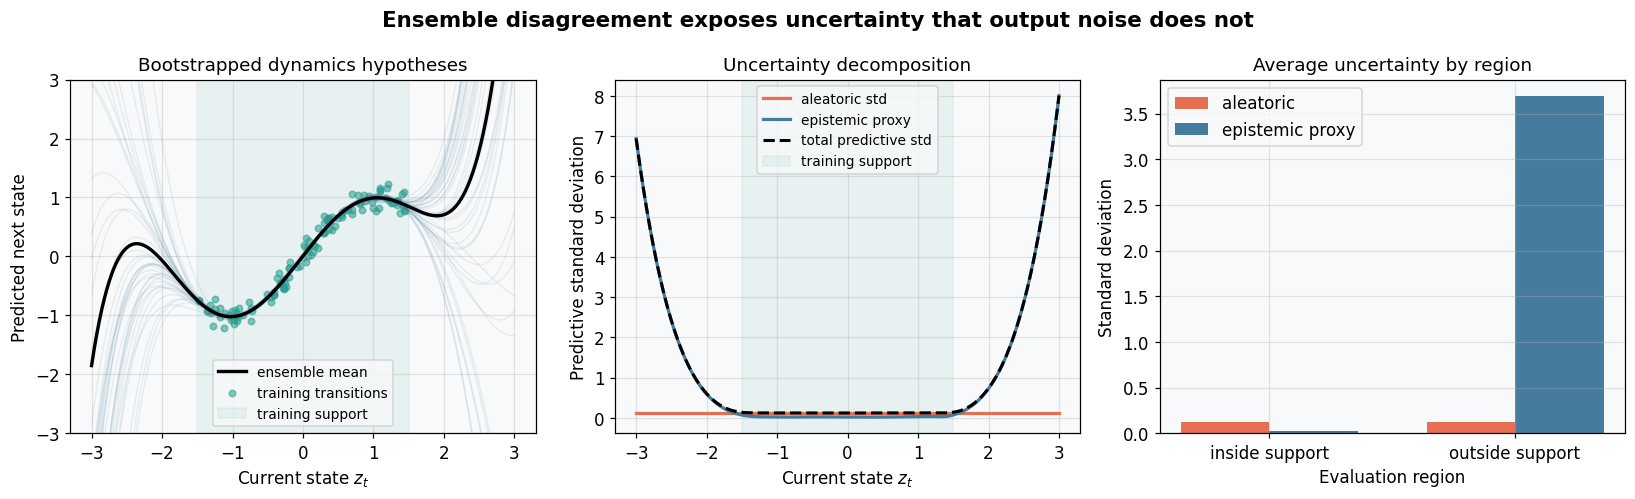

In [5]:
np.random.seed(4)
training_count = 120
training_state = np.random.uniform(-1.5, 1.5, training_count)
aleatoric_sigma = 0.12
training_target = np.sin(1.5 * training_state) + aleatoric_sigma * np.random.randn(training_count)

evaluation_state = np.linspace(-3.0, 3.0, 500)
ensemble_size = 40
ensemble_predictions = np.empty((ensemble_size, len(evaluation_state)))
for member in range(ensemble_size):
    bootstrap_indices = np.random.randint(0, training_count, training_count)
    coefficients = np.polyfit(training_state[bootstrap_indices], training_target[bootstrap_indices], deg=5)
    ensemble_predictions[member] = np.polyval(coefficients, evaluation_state)

ensemble_mean = np.mean(ensemble_predictions, axis=0)
epistemic_sigma = np.std(ensemble_predictions, axis=0)
total_sigma = np.sqrt(aleatoric_sigma ** 2 + epistemic_sigma ** 2)
in_domain = np.abs(evaluation_state) <= 1.5
out_domain = np.abs(evaluation_state) >= 2.2
uncertainty_summary = [
    [aleatoric_sigma, np.mean(epistemic_sigma[in_domain])],
    [aleatoric_sigma, np.mean(epistemic_sigma[out_domain])],
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
fig.suptitle('Ensemble disagreement exposes uncertainty that output noise does not', fontsize=14, fontweight='bold')

for member in range(ensemble_size):
    axes[0].plot(evaluation_state, ensemble_predictions[member], color='#457b9d', alpha=0.10, linewidth=1.0)
axes[0].plot(evaluation_state, ensemble_mean, color='black', linewidth=2.2, label='ensemble mean')
axes[0].scatter(training_state, training_target, s=18, alpha=0.55, color='#2a9d8f', label='training transitions')
axes[0].axvspan(-1.5, 1.5, color='#2a9d8f', alpha=0.08, label='training support')
axes[0].set_ylim(-3.0, 3.0)
axes[0].set_title('Bootstrapped dynamics hypotheses')
axes[0].set_xlabel('Current state $z_t$')
axes[0].set_ylabel('Predicted next state')
axes[0].legend(fontsize=9)

axes[1].plot(evaluation_state, np.full_like(evaluation_state, aleatoric_sigma), color='#e76f51', linewidth=2.1, label='aleatoric std')
axes[1].plot(evaluation_state, epistemic_sigma, color='#457b9d', linewidth=2.1, label='epistemic proxy')
axes[1].plot(evaluation_state, total_sigma, color='black', linewidth=2.0, linestyle='--', label='total predictive std')
axes[1].axvspan(-1.5, 1.5, color='#2a9d8f', alpha=0.08, label='training support')
axes[1].set_title('Uncertainty decomposition')
axes[1].set_xlabel('Current state $z_t$')
axes[1].set_ylabel('Predictive standard deviation')
axes[1].legend(fontsize=9)

summary_array = np.array(uncertainty_summary)
x_positions = np.arange(2)
axes[2].bar(x_positions - 0.18, summary_array[:, 0], width=0.36, color='#e76f51', label='aleatoric')
axes[2].bar(x_positions + 0.18, summary_array[:, 1], width=0.36, color='#457b9d', label='epistemic proxy')
axes[2].set_xticks(x_positions, labels=['inside support', 'outside support'])
axes[2].set_title('Average uncertainty by region')
axes[2].set_xlabel('Evaluation region')
axes[2].set_ylabel('Standard deviation')
axes[2].legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plots show:** Ensemble members agree inside the training interval and diverge sharply outside it. The fixed aleatoric scale does not react to data coverage, while model disagreement does.
2. **Why it looks this way:** Aleatoric variance describes residual process noise under a learned dynamics hypothesis. Bootstrap members encode different hypotheses compatible with finite data, so their disagreement grows where the data no longer constrain the function.
3. **Key takeaway:** Output variance and model uncertainty answer different questions; planning outside support needs an epistemic mechanism such as an ensemble, not only a Gaussian head.

---
## Experiment 5: Particle rollout preserves branches

**Question:** What information disappears when a multimodal rollout is replaced by its mean or by one moment-matched Gaussian?

A latent belief initially contains two persistent motion regimes. Particle trajectories keep those hypotheses separate; their mean travels through an unsupported corridor, and a Gaussian moment match fills the space between modes.

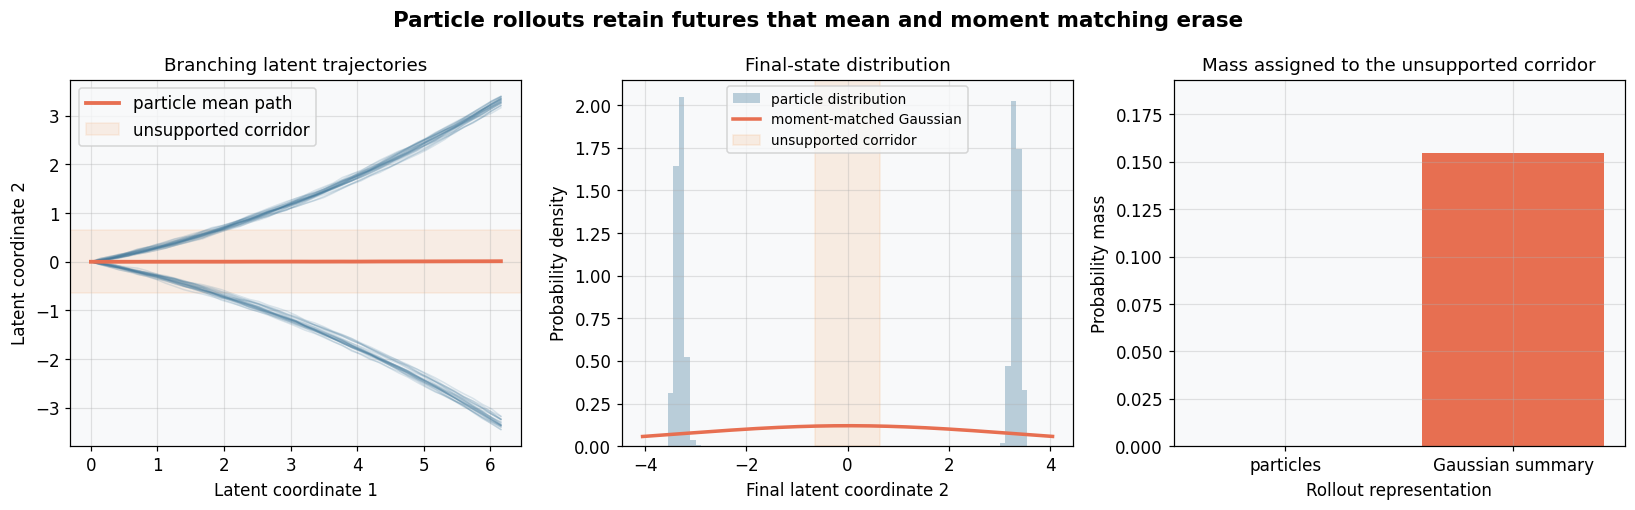

In [6]:
np.random.seed(5)
particle_count = 1600
horizon = 45
regime = np.random.choice([-1.0, 1.0], size=particle_count)
particle_x = np.zeros((horizon, particle_count))
particle_y = np.zeros((horizon, particle_count))

for step in range(1, horizon):
    particle_x[step] = particle_x[step - 1] + 0.14
    vertical_increment = regime * (0.035 + 0.0018 * step)
    particle_y[step] = particle_y[step - 1] + vertical_increment + 0.012 * np.random.randn(particle_count)

mean_x = np.mean(particle_x, axis=1)
mean_y = np.mean(particle_y, axis=1)
final_y = particle_y[-1]
gaussian_mean = np.mean(final_y)
gaussian_sigma = np.std(final_y)
density_grid = np.linspace(final_y.min() - 0.5, final_y.max() + 0.5, 600)
moment_density = normal_density(density_grid, gaussian_mean, gaussian_sigma)
corridor_half_width = 0.65
particle_corridor_mass = np.mean(np.abs(final_y) < corridor_half_width)
gaussian_draws = gaussian_mean + gaussian_sigma * np.random.randn(200000)
gaussian_corridor_mass = np.mean(np.abs(gaussian_draws) < corridor_half_width)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.7))
fig.suptitle('Particle rollouts retain futures that mean and moment matching erase', fontsize=14, fontweight='bold')

for particle in range(0, particle_count, 32):
    axes[0].plot(particle_x[:, particle], particle_y[:, particle], color='#457b9d', alpha=0.18, linewidth=1.0)
axes[0].plot(mean_x, mean_y, color='#e76f51', linewidth=2.5, label='particle mean path')
axes[0].axhspan(-corridor_half_width, corridor_half_width, color='#f4a261', alpha=0.14, label='unsupported corridor')
axes[0].set_title('Branching latent trajectories')
axes[0].set_xlabel('Latent coordinate 1')
axes[0].set_ylabel('Latent coordinate 2')
axes[0].legend()

axes[1].hist(final_y, bins=65, density=True, alpha=0.35, color='#457b9d', label='particle distribution')
axes[1].plot(density_grid, moment_density, color='#e76f51', linewidth=2.3, label='moment-matched Gaussian')
axes[1].axvspan(-corridor_half_width, corridor_half_width, color='#f4a261', alpha=0.16, label='unsupported corridor')
axes[1].set_title('Final-state distribution')
axes[1].set_xlabel('Final latent coordinate 2')
axes[1].set_ylabel('Probability density')
axes[1].legend(fontsize=9)

axes[2].bar(['particles', 'Gaussian summary'], [particle_corridor_mass, gaussian_corridor_mass], color=['#457b9d', '#e76f51'])
axes[2].set_title('Mass assigned to the unsupported corridor')
axes[2].set_xlabel('Rollout representation')
axes[2].set_ylabel('Probability mass')
axes[2].set_ylim(0.0, max(particle_corridor_mass, gaussian_corridor_mass) * 1.25)

plt.tight_layout()
plt.show()

### What you see

1. **What the plots show:** Particles form two coherent trajectory families, but their average runs down the empty center. The moment-matched Gaussian reproduces the first two moments while assigning substantial probability to the unsupported corridor.
2. **Why it looks this way:** Mean propagation discards all dispersion. Moment matching keeps mean and covariance but cannot preserve separated modes, so it replaces two branches with one broad density.
3. **Key takeaway:** Particle trajectories are expensive, but they preserve mode identity and event probabilities that Gaussian summaries can fundamentally misrepresent.

---
## Summary

| Experiment | Key insight |
|---|---|
| 1. Heteroscedastic transition | Local variance is required for calibrated uncertainty across state-action regions. |
| 2. Gaussian NLL | Likelihood rewards accurate means, finite variances, and differentiable sampling through reparameterization. |
| 3. Multimodal futures | A single Gaussian can place probability mass between valid transition modes. |
| 4. Uncertainty decomposition | Aleatoric noise and epistemic model disagreement require different mechanisms. |
| 5. Particle rollout | Mean and moment matching lose branch structure that particles preserve. |

### Connection to Latent-Anything

A stochastic transition adapter should expose distribution family, sampling semantics, log probability, uncertainty type, and calibration domain. `Trajectory` should support particle identities and ensemble hypotheses in addition to mean/covariance summaries, because different representations preserve different answers to planning and risk queries.